In [14]:
import sys
sys.path.append('..')

import numpy as np
import os
import matplotlib.pyplot as plt

from numcodecs import Blosc
from src.utils import unfold_tensor
from types import SimpleNamespace
import time

In [15]:
npz_path = os.path.join(r"..\data\train", "20240520_1200.npz")
npz = np.load(npz_path)

In [16]:
npz.files

['DEMCube',
 'DEMCubeShape',
 'AIACube',
 'AIAErrors',
 'AIACubeShape',
 'logT',
 'scaleFactor']

In [17]:
AIACube = npz["AIACube"]
AIAErrors = npz["AIAErrors"]

In [18]:
compressor = Blosc(cname='zstd', clevel=4, shuffle=2)
AIACube = np.frombuffer(compressor.decode(AIACube), dtype=np.float32).reshape(npz['AIACubeShape'])
AIAErrors = np.frombuffer(compressor.decode(AIAErrors), dtype=np.float32).reshape(npz['AIACubeShape'])

In [ ]:
print(AIACube.shape)
print(AIAErrors.shape)

(6, 4096, 4096)
(6, 4096, 4096)


In [20]:
aia_patches = unfold_tensor(AIACube)
aia_errors_patches = unfold_tensor(AIAErrors)

In [21]:
print(aia_patches.shape)
print(aia_errors_patches.shape)

(256, 6, 256, 256)
(256, 6, 256, 256)


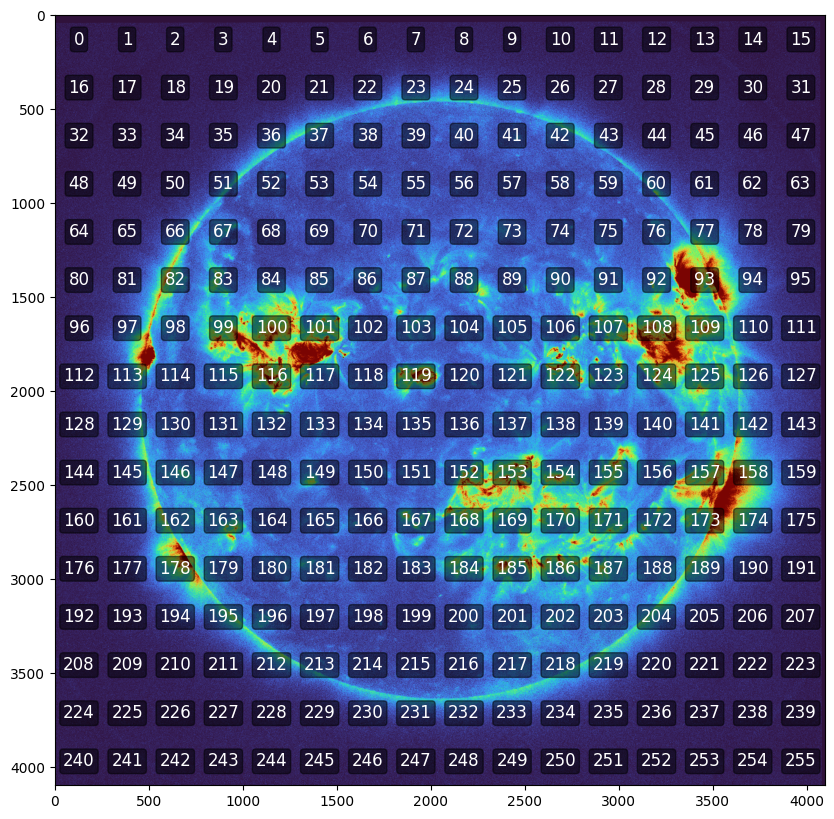

In [9]:
# Plot AIACube channel 0 with patch labels
patch_size = 256
aiacube = AIACube[0]

plt.figure(figsize=(10, 10))
plt.imshow(aiacube, cmap="turbo", vmin=0, vmax=10)

# Overlay patch labels
n_patches_y = aiacube.shape[0] // patch_size
n_patches_x = aiacube.shape[1] // patch_size

for idx_y in range(n_patches_y):
    for idx_x in range(n_patches_x):
        idx = idx_y * n_patches_x + idx_x
        y = idx_y * patch_size + patch_size // 2
        x = idx_x * patch_size + patch_size // 2
        plt.text(x, y, str(idx), color="white", fontsize=12, ha="center", va="center", bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))

#plt.xlabel("X")
#plt.ylabel("Y")
plt.show()

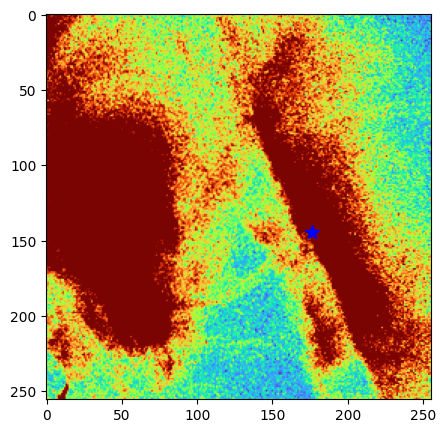

In [10]:
plt.figure(figsize=(5, 5))
plt.imshow(aia_patches[93][0], cmap="turbo", vmin=0, vmax=10)
plt.plot(22*8, 18*8, '*b', markersize=10)
plt.show()

In [11]:
# now with DataLoader
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch

class SimpleAIAData(Dataset):
    def __init__(self, data):
        self.len = None
        self.aia_ds = data[0]
        self.err_ds = data[1]

    def __getitem__(self, idx):

        aia_patch = self.aia_ds[idx]
        aia_error = self.err_ds[idx]

        aia_patch = torch.from_numpy(aia_patch).double()
        aia_error = torch.from_numpy(aia_error).double()
        return aia_patch, aia_error

    def __len__(self):
        if self.len is None:
            self.len = len(self.aia_ds)
        return self.len

aia_data = SimpleAIAData((aia_patches, aia_errors_patches))

In [12]:
aia_ds = torch.utils.data.Subset(aia_data, [93])

aia_loader = DataLoader(
    aia_ds,
    batch_size=1,   
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [13]:
# get the batch from the dataloader
aia_input, aia_errors = next(iter(aia_loader))
aia_input = aia_input[:, :, 22*8:22*8+1, 18*8:18*8+1]
aia_errors = aia_errors[:, :, 22*8:22*8+1, 18*8:18*8+1]

c:\Users\Usuario\anaconda3\envs\dem-dl\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [14]:
aia_input.shape

torch.Size([1, 6, 1, 1])

In [15]:
device = torch.device("cpu")

In [16]:
from src.utils import getBasis
RData = np.load("../RData.npz")
R, logT = RData['R'], RData['logT']
wavelengths = [94, 131, 171, 193, 211, 335]
scale = 10**26
R = (R * scale).astype(np.float64)
basisAlphas = list(map(float, "0.0_0.1_0.2".split("_")))
B = getBasis(R, logT, basisAlphas)

RData = {'R': R, 'B': B}
# total matrix is R (nObs x nLogTBins) @ B (nLogTBins x nBasis)
D = R@B
D = torch.tensor(D, dtype=torch.float64).to(device)  # [N, n_temps]
B = torch.tensor(B, dtype=torch.float64).to(device)  # [nLogTBins, n_basis]

## BP

In [17]:
sys.path.append(r"..\scripts")
from fullBP import invertDEMCube

args_inversion = {
    "crop": "",
    "fitfn": "lp",
    "parallel": -1,
    "tolfac":1.4,
    "zerochill": False,
    }

args_inversion = SimpleNamespace(**args_inversion)  # convert dict to namespace
print(args_inversion)
DEMC, results = invertDEMCube(aia_input.squeeze(0).cpu().numpy(), aia_errors.squeeze(0).cpu().numpy(), RData, args=args_inversion)

namespace(crop='', fitfn='lp', parallel=-1, tolfac=1.4, zerochill=False)
Setup took 0.00
Cleaning up 0 pixels
Cleaning up 0 pixels
BP took 10.93
Repacking took 0.00


In [18]:
result_lp = torch.tensor(results[0], dtype=torch.float64).to(device)  # [B, H, W, n_temps]
result_lp = result_lp.unsqueeze(0) # [B, H, W, n_temps]

In [19]:
result_lp.shape

torch.Size([1, 54])

In [20]:
def coeffs_to_dem(x_flat, B):
    """Convierte coeficientes de base x [1, 54] a DEM xi [18]"""
    with torch.no_grad():
        xi = torch.matmul(x_flat, B.T)  # [1, 18]
    return xi.squeeze().cpu().numpy()  # [18]

In [22]:
dem_lp = coeffs_to_dem(result_lp, B)
print(dem_lp.shape)

(18,)


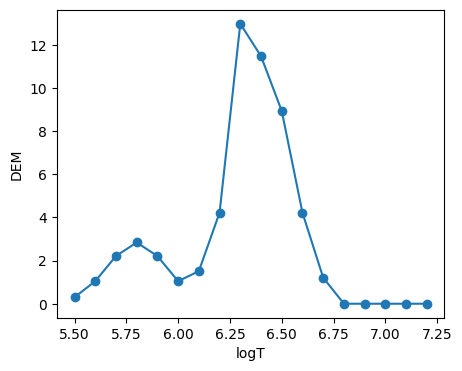

In [23]:
plt.figure(figsize=(5, 4))
plt.plot(logT, dem_lp, '-o')
plt.xlabel("logT")
plt.ylabel("DEM")
plt.show()

# Optm. Methods

In [26]:
args = {}
args = SimpleNamespace(**args)  # convert dict to namespace

from src.losses import BarrierLoss
args.alpha_l1 = 1
args.alpha_l2 = 0
args.mu = 1
args.alpha_fit = 0
barrier_loss = BarrierLoss(D=D, B=B, R=R, args=args)

In [27]:
from src.utils import compute_photon_error_bounds
import torch.nn as nn

## LBFGS

In [28]:
def closure():
    aia_input_dev = aia_input.cpu()
    aia_errors_dev = aia_errors.cpu()
    lbfgs.zero_grad()
    
    aia_obs_flat = aia_input_dev.permute(0, 2, 3, 1).reshape(-1, aia_input_dev.shape[1])  # [B * H * W, n_channels]
    # compute lower and upper bounds and flatten them
    lb, ub = compute_photon_error_bounds(aia_obs=aia_input_dev, aia_errors=aia_errors_dev)
    lb = lb.reshape(-1, lb.shape[-1])  # [B*H*W, n_channels]
    ub = ub.reshape(-1, ub.shape[-1])  # [B*H*W, n_channels]
    x = nn.functional.softplus(x_lbfgs)  # ensure x is positive
    loss = barrier_loss(x, aia_obs=aia_obs_flat, lb=lb, ub=ub)
    loss.backward()
    return loss

x_lbfgs = torch.ones(1, 54, device=device, requires_grad=True, dtype=torch.float64)
#x_lbfgs = x
lbfgs = torch.optim.LBFGS([x_lbfgs], lr=1e-6, max_iter=100, line_search_fn='strong_wolfe', tolerance_change=1e-12, tolerance_grad=1e-32)

barrier_loss.mu = 1000
for step in range(10000):
    loss = lbfgs.step(closure)
    if step % 1000 == 0:
        print(f"Step {step}, loss: {loss.item():.6f}")
        barrier_loss.mu *= 1
x_star = nn.functional.softplus(x_lbfgs)  # [B, n_basis]

Step 0, loss: 7060157285.812512
Step 1000, loss: 18.354697
Step 2000, loss: 18.354697
Step 3000, loss: 18.354697
Step 4000, loss: 18.354697
Step 5000, loss: 18.354697
Step 6000, loss: 18.354697
Step 7000, loss: 18.354697
Step 8000, loss: 18.354697
Step 9000, loss: 18.354697


In [29]:
x_basis = x_star.detach()
x_basis.shape

torch.Size([1, 54])

In [30]:
dem_lbfgs = coeffs_to_dem(x_basis, B)
print(dem_lbfgs.shape)

(18,)


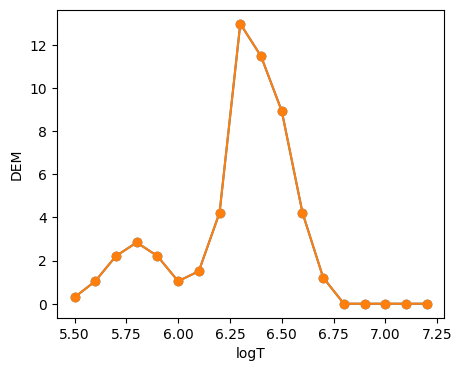

In [31]:
plt.figure(figsize=(5, 4))
plt.plot(logT, dem_lp, '-o')
plt.plot(logT, dem_lbfgs, '-o')
plt.xlabel("logT")
plt.ylabel("DEM")
plt.show()

In [32]:
print(dem_lp)
print(dem_lbfgs)

[ 0.29915083  1.04413897  2.21044438  2.83827219  2.21044963  1.04414388
  1.50842445  4.22077215 12.97855133 11.47328143  8.93540469  4.22079199
  1.20928006  0.          0.          0.          0.          0.        ]
[ 0.29915081  1.04413891  2.21044426  2.83827205  2.21044953  1.04414384
  1.50842503  4.22077417 12.97854444 11.47328689  8.93540895  4.220794
  1.20928063  0.          0.          0.          0.          0.        ]


In [47]:
from src.utils import getBasis
RData = np.load("../RData.npz")
R, logT = RData['R'], RData['logT']
wavelengths = [94, 131, 171, 193, 211, 335]
scale = 10**26
R = (R * scale).astype(np.float64)
basisAlphas = list(map(float, "0.0_0.1_0.2".split("_")))
B = getBasis(R, logT, basisAlphas)

RData = {'R': R, 'B': B}
# total matrix is R (nObs x nLogTBins) @ B (nLogTBins x nBasis)
D = R@B
D = torch.tensor(D, dtype=torch.float64).to(device)  # [N, n_temps]
B = torch.tensor(B, dtype=torch.float64).to(device)  # [nLogTBins, n_basis]

aia_input_dev = aia_input.cpu()
aia_errors_dev = aia_errors.cpu()
lb, ub = compute_photon_error_bounds(aia_obs=aia_input_dev, aia_errors=aia_errors_dev)

args = {}
args = SimpleNamespace(**args)  # convert dict to namespace

from src.losses import BarrierLoss
args.alpha_l1 = 1
args.alpha_l2 = 0
args.mu = 1
args.alpha_fit = 0
barrier_loss = BarrierLoss(D=D, B=B, R=R, args=args)


def run_experiment(optimizer_name, n_steps=10000, mu_schedule=None):
    if mu_schedule is None:
        mu_schedule = [(0,    10.0),
                       (1000, 100.0),
                       (2000, 1000.0)]

    def get_mu(step):
        mu = mu_schedule[0][1]
        for (s, m) in mu_schedule:
            if step >= s:
                mu = m
        return mu

    # ── preparar pixel: shape [1, 6] ─────────────────────────────────────────
    aia_obs_flat = aia_input.permute(0,2,3,1).reshape(-1, aia_input.shape[1])  # [1, 6]
    lb_flat = lb.reshape(-1, lb.shape[-1])   # [1, 6]
    ub_flat = ub.reshape(-1, ub.shape[-1])   # [1, 6]

    # ── variable libre z ─────────────────────────────────────────────────────
    z = nn.Parameter(torch.zeros(1, 54, dtype=torch.float64))

    # ── optimizador ──────────────────────────────────────────────────────────
    if optimizer_name == "SGD":
        opt = torch.optim.SGD([z], lr=1e-4)
    elif optimizer_name == "Adam":
        opt = torch.optim.Adam([z], lr=1e-3)
    elif optimizer_name == "Adadelta":
        opt = torch.optim.Adadelta([z], lr=1.0)
    elif optimizer_name == "Muon":
        opt = torch.optim.SGD([z], lr=1e-4)
    elif optimizer_name == "Rprop":
        opt = torch.optim.Rprop([z], lr=1e-3)
    elif optimizer_name == "RMSprop":
        opt = torch.optim.RMSprop([z], lr=1e-3)
    elif optimizer_name == "LBFGS":
        opt = torch.optim.LBFGS([z], lr=0.1, max_iter=20,
                                 line_search_fn='strong_wolfe')

    history = {"loss": [], "violation": [], "l1": [], "time": []}
    t0 = time.time()

    for step in range(n_steps):
        # actualizar mu en barrier_loss directamente
        barrier_loss.mu = get_mu(step)

        x = nn.functional.softplus(z)  # [1, 54], siempre positivo

        if optimizer_name == "LBFGS":
            def closure():
                opt.zero_grad()
                x_c = nn.functional.softplus(z)
                loss = barrier_loss(x_c, aia_obs=aia_obs_flat, lb=lb_flat, ub=ub_flat)
                loss.backward()
                return loss
            opt.step(closure)
            with torch.no_grad():
                x = nn.functional.softplus(z)
                loss = barrier_loss(x, aia_obs=aia_obs_flat, lb=lb_flat, ub=ub_flat)
        else:
            opt.zero_grad()
            loss = barrier_loss(x, aia_obs=aia_obs_flat, lb=lb_flat, ub=ub_flat)
            loss.backward()
            opt.step()

        # métricas separadas para el historial
        with torch.no_grad():
            x_now = nn.functional.softplus(z)
            Dx    = x_now @ D.T                                      # [1, 6]
            viol  = (torch.relu(lb_flat - Dx)**2 +
                     torch.relu(Dx - ub_flat)**2).sum().item()
            l1    = x_now.sum().item()

        history["loss"].append(loss.item())
        history["violation"].append(viol)
        history["l1"].append(l1)
        history["time"].append(time.time() - t0)

    # solución final
    with torch.no_grad():
        x_star  = nn.functional.softplus(z).squeeze(0)   # [54]
        xi_star = (B @ x_star).cpu().numpy()              # [18]

    return history, x_star.cpu().numpy(), xi_star


# ── Correr todos los optimizadores ───────────────────────────────────────────
optimizers = ["SGD", "Adam", "Adadelta", "Muon", 'Rprop', "RMSprop", "LBFGS"]
results_exp    = {}
colors     = {"SGD": "gray", "Adam": "blue", "Adadelta": "orange", "Muon": "purple", "Rprop": "brown", "RMSprop": "green", "LBFGS": "red"}

for name in optimizers:
    print(f"Corriendo {name}...")
    history, x_star, xi_star = run_experiment(name)
    results_exp[name] = {"history": history, "x_star": x_star, "xi_star": xi_star}
    print(f"  L1 final:        {history['l1'][-1]:.4f}")
    print(f"  Violación final: {history['violation'][-1]:.6f}")
    print(f"  Tiempo total:    {history['time'][-1]:.2f}s\n")

Corriendo SGD...
  L1 final:        174.4745
  Violación final: 1352173.277416
  Tiempo total:    26.17s

Corriendo Adam...
  L1 final:        37.2218
  Violación final: 1.093311
  Tiempo total:    26.96s

Corriendo Adadelta...
  L1 final:        31.7289
  Violación final: 0.000000
  Tiempo total:    27.54s

Corriendo Muon...
  L1 final:        174.4745
  Violación final: 1352173.277416
  Tiempo total:    24.53s

Corriendo Rprop...
  L1 final:        34.1281
  Violación final: 0.000000
  Tiempo total:    28.17s

Corriendo RMSprop...
  L1 final:        29.6387
  Violación final: 0.000000
  Tiempo total:    26.26s

Corriendo LBFGS...
  L1 final:        18.3547
  Violación final: 0.000000
  Tiempo total:    150.28s



In [37]:
plt.rcParams["figure.dpi"] = 100
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'

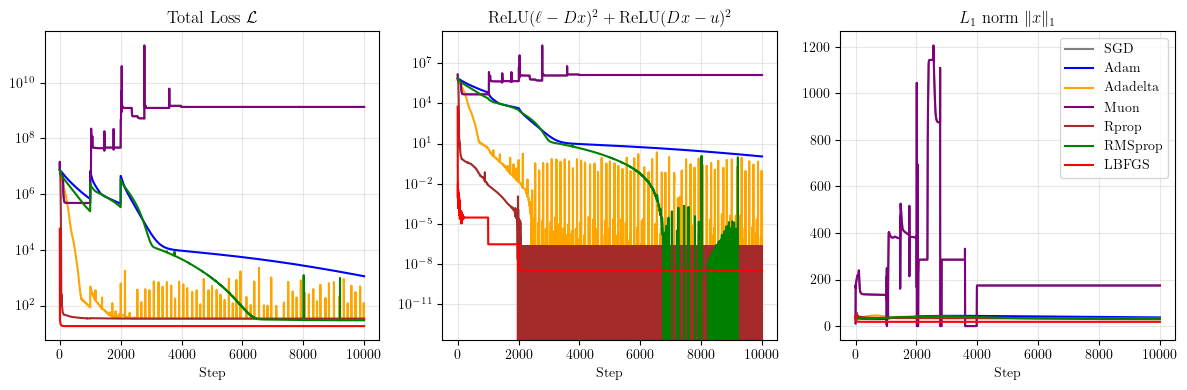

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for name in optimizers:
    h = results_exp[name]["history"]
    axes[0].plot(h["loss"],      label=name, color=colors[name])
    axes[1].plot(h["violation"], label=name, color=colors[name])
    axes[2].plot(h["l1"],        label=name, color=colors[name])
axes[0].set_title(r"Total Loss $\mathcal{L}$")     
axes[0].set_yscale("log")
axes[1].set_title(r"$\mathrm{ReLU}(\ell - Dx)^2 + \mathrm{ReLU}(Dx - u)^2$")
axes[1].set_yscale("log")
axes[2].set_title(r"$L_1$ norm $\|x\|_1$")
for ax in axes:
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

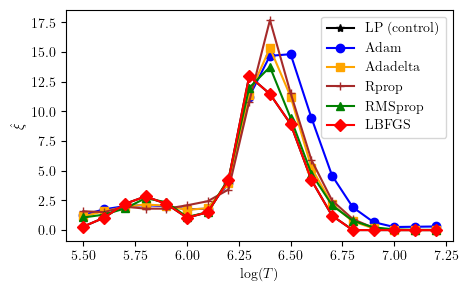

In [55]:
plt.figure(figsize=(5, 3))
plt.plot(logT, dem_lp.flatten(), '-*', color="black",  label="LP (control)")
#plt.bar(logT, results_exp["SGD"]["xi_star"].flatten(), color=colors["SGD"], width=0.08, alpha=0.5, label="SGD")
plt.plot(logT, results_exp["Adam"]["xi_star"].flatten(), '-o', color=colors["Adam"], label="Adam")
plt.plot(logT, results_exp["Adadelta"]["xi_star"].flatten(), '-s', color=colors["Adadelta"], label="Adadelta")
#plt.plot(logT, results_exp["Muon"]["xi_star"].flatten(), '-x', color=colors["Muon"], label="Muon")
plt.plot(logT, results_exp["Rprop"]["xi_star"].flatten(), '-+', color=colors["Rprop"], label="Rprop")
plt.plot(logT, results_exp["RMSprop"]["xi_star"].flatten(), '-^', color=colors["RMSprop"], label="RMSprop")
plt.plot(logT, results_exp["LBFGS"]["xi_star"].flatten(), '-D', color=colors["LBFGS"], label="LBFGS")
plt.xlabel(r"$\log(T)$")
plt.ylabel(r"$\hat{\xi}$")
plt.legend()
plt.show()